# 1... FRED Data Extraction


Source: https://fred.stlouisfed.org/tags/series?t=weekly&et=&ptic=3616&ob=pv&od=&tg=&tt=


Top 25 Most Popular Week (FRED)


1. MORTGAGE30US - 30-Year Fixed Rate Mortgage Average in the United States

2. FF - Federal Funds Effective Rate

3. WALCL - Total Assets (Less Eliminations from Consolidation): Wednesday Level

4. WGS10YR - Market Yield on U.S. Treasury Securities at 10-Year Constant
Maturity, Quoted on an **Investment Basis**

5. WFII10 - Market Yield on U.S. Treasury Securities at 10-Year Constant Maturity, Quoted on an Investment Basis, **Inflation-Indexed**

6. WAAA -  Moody's Seasoned Aaa Corporate Bond Yield

7. WTB3MS - 3-Month Treasury Bill Secondary Market Rate, Discount Basis

8. ICSA - Initial Claims

9. WGS1YR - Market Yield on U.S. Treasury Securities at 1-Year Constant Maturity, Quoted on an Investment Basis

10. WGS2YR - Market Yield on U.S. Treasury Securities at 2-Year Constant Maturity, Quoted on an Investment Basis

11. NFCI -  Chicago Fed National Financial Conditions Index

12. CCLACBW027SBOG - Consumer Loans: Credit Cards and Other Revolving Plans, All Commercial Banks

13. WTREGEN - Liabilities and Capital: Liabilities: Deposits with F.R. Banks, Other Than Reserve Balances: U.S. Treasury, General Account: Week Average

14. WGS5YR - Market Yield on U.S. Treasury Securities at 5-Year Constant Maturity, Quoted on an Investment Basis

15. WBAA - Moody's Seasoned Baa Corporate Bond Yield

16. DPSACBW027SBOG -  Deposits, All Commercial Banks

17. WCOILWTICO - Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma

18. WGS30YR - Market Yield on U.S. Treasury Securities at 30-Year Constant Maturity, Quoted on an Investment Basis

19. WRESBAL - Liabilities and Capital: Other Factors Draining Reserve Balances: Reserve Balances with Federal Reserve Banks: Week Average

20. WGS20YR - Market Yield on U.S. Treasury Securities at 20-Year Constant Maturity, Quoted on an Investment Basis

21. H41RESPPALDKNWW - Assets: Liquidity and Credit Facilities: Loans: Bank Term Funding Program, Net: Wednesday Level

22. MORTGAGE15US - 15-Year Fixed Rate Mortgage Average in the United States

23. WPRIME - Bank Prime Loan Rate

24. CCSA - Continued Claims (Insured Unemployment)

25. TOTCI - Commercial and Industrial Loans, All Commercial Banks


In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import requests

import yfinance as yf

In [2]:
# FRED API Key
api_key = '2817ae78096d0d0704e0c0e65bc3392e'

In [3]:
# Function to fetch FRED data
def get_fred_data(symbol):
    base_url = f"https://api.stlouisfed.org/fred/series/observations?series_id={symbol}&api_key={api_key}&file_type=json"
    response = requests.get(base_url)
    data = response.json()

    # Convert the data into a DataFrame
    df = pd.DataFrame(data['observations'])

    # Rename the 'value' column to the symbol name
    df = df[['date', 'value']].rename(columns={'value': symbol})

    # Convert 'value' column to numeric
    df[symbol] = pd.to_numeric(df[symbol], errors='coerce')

    # Set 'date' as the index
    df['date'] = pd.to_datetime(df['date'])
    df.set_index('date', inplace=True)

    return df


In [4]:
# List of symbols
symbols = ['MORTGAGE30US', 'FF', 'WALCL','WGS10YR', 'WFII10', 'WAAA', 'WTB3MS','ICSA','WGS1YR','WGS2YR','NFCI','CCLACBW027SBOG','WTREGEN','WGS5YR','WBAA','DPSACBW027SBOG', 'WCOILWTICO', 'WGS30YR', 'WRESBAL', 'WGS20YR', 'H41RESPPALDKNWW', 'MORTGAGE15US', 'WPRIME' , 'CCSA' , 'TOTCI' ]
#symbols = ['PCECTPI', 'GDP', 'CPIAUCSL']

# Fetch and combine data
dataframes = []
for symbol in symbols:
    df = get_fred_data(symbol)
    dataframes.append(df)

# Combine all the DataFrames into one
full_macro_data = pd.concat(dataframes, axis=1)

In [5]:
def preprocess_macrodata(df):
  # Resampling to weekly
  weekly_data = pd.DataFrame(df.resample('W-MON').last())

  # Forward filling missing information
  weekly_data_filled = weekly_data.ffill()

  # Formatting index
  weekly_data_filled.index = weekly_data_filled.index.tz_localize(None)  # Remove timezone
  weekly_data_filled.index = weekly_data_filled.index.strftime('%Y-%m-%d')  # Format to year-month-day

  # Verifying and calculating missing information
  miss_data = weekly_data_filled

  missing_values = miss_data.isnull().sum()

  missing_percentage = pd.DataFrame((miss_data.isnull().sum() / len(miss_data)) * 100)

  print("\nMissing Value Percentage per Column:\n", missing_percentage)

  plt.figure(figsize=(10, 6))
  sns.heatmap(weekly_data_filled.isnull(), cbar=False)
  plt.title('Missing Values Heatmap')
  plt.show()

  weekly_data_filled.info()

  return weekly_data_filled



Missing Value Percentage per Column:
                          0
MORTGAGE30US     24.310438
FF                0.703083
WALCL            69.064359
WGS10YR          11.276366
WFII10           69.118442
WAAA             11.276366
WTB3MS            0.000000
ICSA             18.334235
WGS1YR           11.276366
WGS2YR           31.611682
NFCI             23.985938
CCLACBW027SBOG   65.575987
WTREGEN          45.159546
WGS5YR           11.276366
WBAA             11.276366
DPSACBW027SBOG   26.798269
WCOILWTICO       45.132504
WGS30YR          32.612223
WRESBAL          42.320173
WGS20YR          11.276366
H41RESPPALDKNWW  69.064359
MORTGAGE15US     53.109789
WPRIME            2.244456
CCSA             18.334235
TOTCI            26.798269


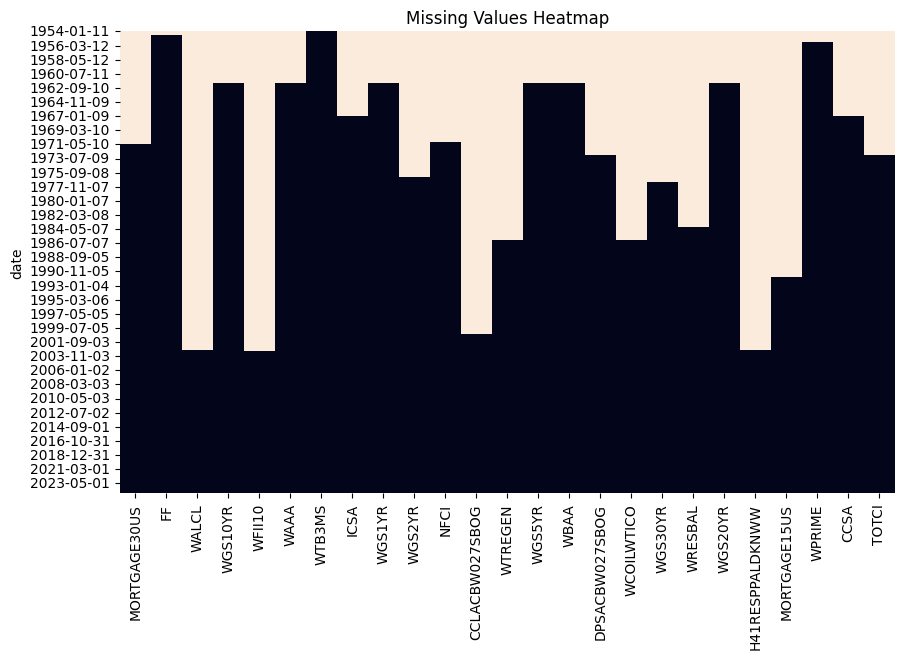

<class 'pandas.core.frame.DataFrame'>
Index: 3698 entries, 1954-01-11 to 2024-11-18
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MORTGAGE30US     2799 non-null   float64
 1   FF               3672 non-null   float64
 2   WALCL            1144 non-null   float64
 3   WGS10YR          3281 non-null   float64
 4   WFII10           1142 non-null   float64
 5   WAAA             3281 non-null   float64
 6   WTB3MS           3698 non-null   float64
 7   ICSA             3020 non-null   float64
 8   WGS1YR           3281 non-null   float64
 9   WGS2YR           2529 non-null   float64
 10  NFCI             2811 non-null   float64
 11  CCLACBW027SBOG   1273 non-null   float64
 12  WTREGEN          2028 non-null   float64
 13  WGS5YR           3281 non-null   float64
 14  WBAA             3281 non-null   float64
 15  DPSACBW027SBOG   2707 non-null   float64
 16  WCOILWTICO       2029 non-null   float64
 17  WGS3

In [6]:
macro_weekly_prep = preprocess_macrodata(full_macro_data)

In [7]:
# Subsetting the macro indicators dataframe
macro_weekly_subset = macro_weekly_prep.loc['1993-01-01':'2024-11-10']
macro_weekly_subset.head()

,MORTGAGE30US,FF,WALCL,WGS10YR,WFII10,WAAA,WTB3MS,ICSA,WGS1YR,WGS2YR,...,DPSACBW027SBOG,WCOILWTICO,WGS30YR,WRESBAL,WGS20YR,H41RESPPALDKNWW,MORTGAGE15US,WPRIME,CCSA,TOTCI
date,,,,,,,,,,,,,,,,,,,,,
1993-01-04,8.14,2.86,NaN,6.70,NaN,7.90,3.15,341000.0,3.62,4.59,...,2481.8112,19.63,7.39,26.519,7.36,NaN,7.68,6.0,2729000.0,595.7721
1993-01-11,8.07,3.03,NaN,6.67,NaN,7.92,3.09,354000.0,3.60,4.52,...,2490.7592,19.00,7.38,26.624,7.36,NaN,7.60,6.0,2697000.0,595.1644
1993-01-18,8.04,2.98,NaN,6.68,NaN,7.96,3.00,352000.0,3.50,4.43,...,2491.0436,18.62,7.43,23.550,7.36,NaN,7.56,6.0,2749000.0,594.3448
1993-01-25,8.00,3.10,NaN,6.59,NaN,7.90,2.99,341000.0,3.47,4.37,...,2489.7747,18.61,7.31,24.521,7.36,NaN,7.51,6.0,2727000.0,595.5170
1993-02-01,7.86,2.94,NaN,6.46,NaN,7.84,2.92,340000.0,3.41,4.24,...,2489.0028,19.90,7.23,20.618,7.36,NaN,7.37,6.0,2663000.0,596.4033


In [8]:
macro_weekly_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1662 entries, 1993-01-04 to 2024-11-04
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MORTGAGE30US     1662 non-null   float64
 1   FF               1662 non-null   float64
 2   WALCL            1142 non-null   float64
 3   WGS10YR          1662 non-null   float64
 4   WFII10           1140 non-null   float64
 5   WAAA             1662 non-null   float64
 6   WTB3MS           1662 non-null   float64
 7   ICSA             1662 non-null   float64
 8   WGS1YR           1662 non-null   float64
 9   WGS2YR           1662 non-null   float64
 10  NFCI             1662 non-null   float64
 11  CCLACBW027SBOG   1271 non-null   float64
 12  WTREGEN          1662 non-null   float64
 13  WGS5YR           1662 non-null   float64
 14  WBAA             1662 non-null   float64
 15  DPSACBW027SBOG   1662 non-null   float64
 16  WCOILWTICO       1662 non-null   float64
 17  WGS3

In [9]:
# Display the result
macro_weekly_subset.tail(10)

,MORTGAGE30US,FF,WALCL,WGS10YR,WFII10,WAAA,WTB3MS,ICSA,WGS1YR,WGS2YR,...,DPSACBW027SBOG,WCOILWTICO,WGS30YR,WRESBAL,WGS20YR,H41RESPPALDKNWW,MORTGAGE15US,WPRIME,CCSA,TOTCI
date,,,,,,,,,,,,,,,,,,,,,
2024-09-02,6.35,5.33,7123238.0,3.85,1.70,4.81,4.98,228000.0,4.37,3.87,...,17672.4253,76.36,4.14,3313.566,4.23,98872.0,5.51,8.5,1843000.0,2769.9911
2024-09-09,6.35,5.33,7112567.0,3.77,1.71,4.75,4.95,231000.0,4.22,3.76,...,17724.5143,70.02,4.06,3243.002,4.14,98335.0,5.47,8.5,1821000.0,2774.1732
2024-09-16,6.20,5.33,7115001.0,3.67,1.62,4.67,4.85,222000.0,4.08,3.62,...,17715.6384,68.82,3.98,3320.818,4.05,97667.0,5.27,8.5,1827000.0,2771.0666
2024-09-23,6.09,5.33,7109137.0,3.69,1.56,4.63,4.66,219000.0,3.95,3.58,...,17759.7709,72.14,4.01,3313.281,4.06,94785.0,5.15,8.5,1819000.0,2778.1774
2024-09-30,6.08,4.83,7080059.0,3.76,1.59,4.69,4.51,225000.0,3.91,3.55,...,17777.4023,70.22,4.11,3169.149,4.15,85941.0,5.16,8.0,1858000.0,2786.0544
2024-10-07,6.12,4.83,7046925.0,3.83,1.63,4.74,4.50,260000.0,4.03,3.71,...,17830.7850,71.83,4.16,3089.598,4.22,71468.0,5.25,8.0,1869000.0,2787.9960
2024-10-14,6.32,4.83,7046840.0,4.06,1.76,4.91,4.54,242000.0,4.22,3.98,...,17761.0668,75.69,4.35,3186.207,4.41,68883.0,5.41,8.0,1888000.0,2776.1931
2024-10-21,6.44,4.83,7039284.0,4.06,1.77,4.90,4.53,228000.0,4.19,3.95,...,17846.7189,70.81,4.35,3209.877,4.40,66833.0,5.63,8.0,1853000.0,2786.5380
2024-10-28,6.54,4.83,7029408.0,4.22,1.91,5.08,4.51,218000.0,4.26,4.06,...,17833.5990,71.59,4.49,3230.145,4.56,59717.0,5.71,8.0,1884000.0,2786.4404


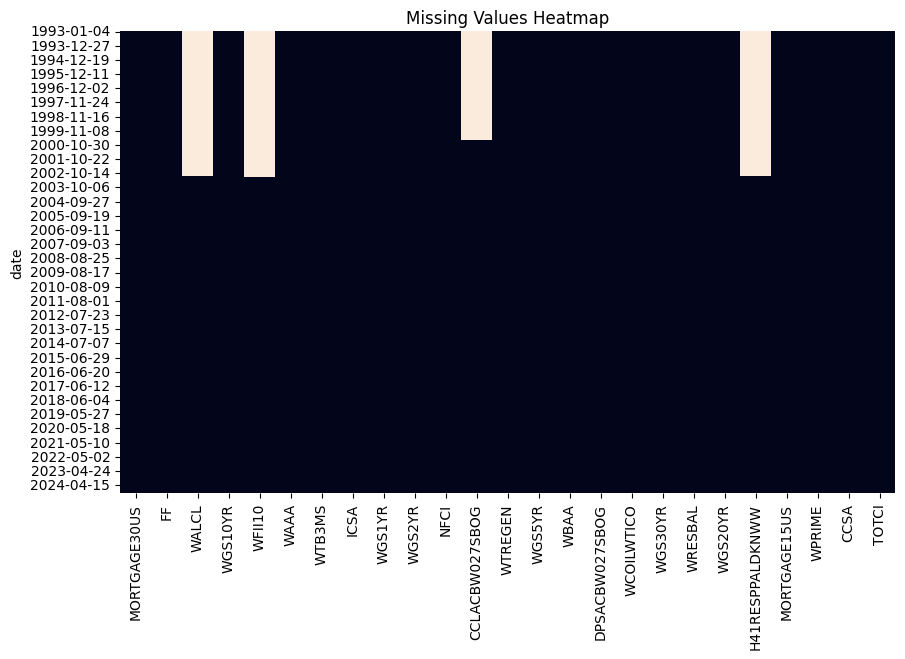

In [10]:
# Checking missing values in the subset data
plt.figure(figsize=(10, 6))
sns.heatmap(macro_weekly_subset.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

# 2... Indices Data Extraction

**Major Indices**

United States (S&P 500): Symbol: ^GSPC

United States (Dow Jones Industrial Average): Symbol: ^DJI

United States (Nasdaq Composite): Symbol: ^IXIC

United Kingdom (FTSE 100): Symbol: ^FTSE

Germany (DAX): Symbol: ^GDAXI

France (CAC 40): Symbol: ^FCHI

Japan (Nikkei 225): Symbol: ^N225

Hong Kong (Hang Seng Index): Symbol: ^HSI

Canada (S&P/TSX Composite Index): Symbol: ^GSPTSE

Australia (S&P/ASX 200): Symbol: ^AXJO

In [11]:
# List of major stock indices
indices = ["^GSPC", "^DJI", "^IXIC", "^FTSE", "^GDAXI", "^FCHI", "^N225", "^HSI", "^GSPTSE", "^AXJO"]

# Download historical data for all indices (1 year period, daily data)
indices_data = yf.download(indices, period="max", interval="1d")


[*********************100%***********************]  10 of 10 completed


In [12]:
def preprocess_indices(df):
  # Flatten the MultiIndex to a single level by combining the levels
  df.columns = ['_'.join(col).strip() for col in df.columns.values]

  # Calculating new variables
  ## Copying S&P500 variables
  df['SP500_Open'] = df['Open_^GSPC']
  df.drop('Open_^GSPC', axis=1, inplace=True)
  df['SP500_Close'] = df['Close_^GSPC']
  df.drop('Close_^GSPC', axis=1, inplace=True)
  df['SP500_Volume'] = df['Volume_^GSPC']
  df.drop('Volume_^GSPC', axis=1, inplace=True)

  ## Weekly Volatility
  max_7d = df['High_^GSPC'].rolling(window=7).max()
  min_7d = df['Low_^GSPC'].rolling(window=7).min()
  df['SP500_Wk_Vol'] = max_7d - min_7d

  # Droping unused variables
  df = df.drop(df.columns[df.columns.str.startswith('Adj')], axis=1)
  df = df.drop(df.columns[df.columns.str.startswith('Open')], axis=1)
  df = df.drop(df.columns[df.columns.str.startswith('High')], axis=1)
  df = df.drop(df.columns[df.columns.str.startswith('Low')], axis=1)


  # Resampling to weekly
  weekly_data = pd.DataFrame(df.resample('W-MON').last())

  # Forward filling missing information
  weekly_data_filled = weekly_data.ffill()

  # Formatting index
  weekly_data_filled.index = weekly_data_filled.index.tz_localize(None)  # Remove timezone
  weekly_data_filled.index = weekly_data_filled.index.strftime('%Y-%m-%d')  # Format to year-month-day

  # Verifying and calculating missing information
  miss_data = weekly_data_filled

  missing_values = miss_data.isnull().sum()

  missing_percentage = pd.DataFrame((miss_data.isnull().sum() / len(miss_data)) * 100)

  print("\nMissing Value Percentage per Column:\n", missing_percentage)

  plt.figure(figsize=(10, 6))
  sns.heatmap(weekly_data_filled.isnull(), cbar=False)
  plt.title('Missing Values Heatmap')
  plt.show()

  weekly_data_filled.info()

  return weekly_data_filled


Missing Value Percentage per Column:
                         0
Close_^AXJO     66.969937
Close_^DJI      66.060127
Close_^FCHI     64.161392
Close_^FTSE     57.812500
Close_^GDAXI    61.926424
Close_^GSPTSE   53.144778
Close_^HSI      60.897943
Close_^IXIC     44.481804
Close_^N225     38.212025
Volume_^AXJO    66.969937
Volume_^DJI     66.060127
Volume_^FCHI    64.161392
Volume_^FTSE    57.812500
Volume_^GDAXI   61.926424
Volume_^GSPTSE  53.144778
Volume_^HSI     60.897943
Volume_^IXIC    44.481804
Volume_^N225    38.212025
SP500_Open       0.000000
SP500_Close      0.000000
SP500_Volume     0.000000
SP500_Wk_Vol     0.039557


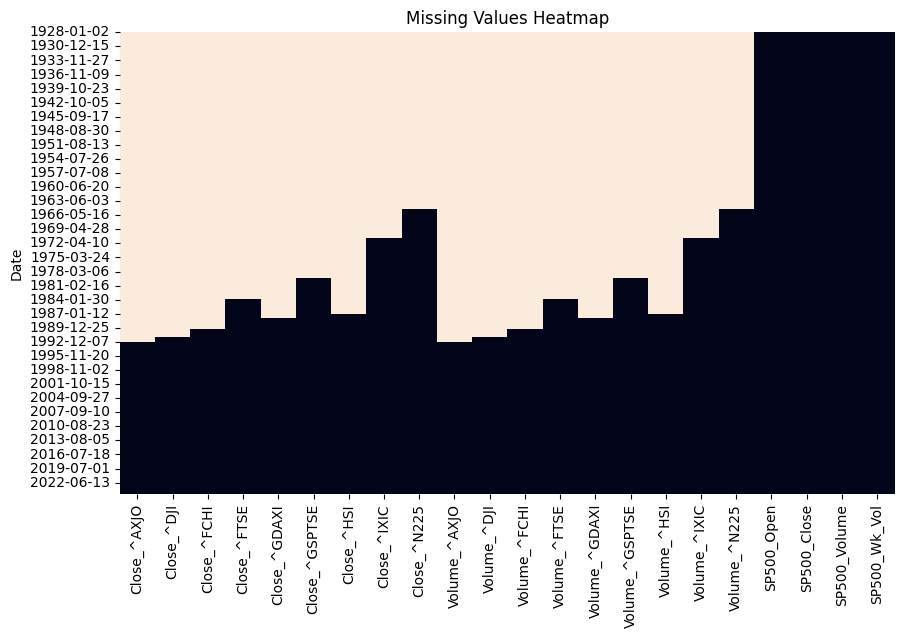

<class 'pandas.core.frame.DataFrame'>
Index: 5056 entries, 1928-01-02 to 2024-11-18
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close_^AXJO     1670 non-null   float64
 1   Close_^DJI      1716 non-null   float64
 2   Close_^FCHI     1812 non-null   float64
 3   Close_^FTSE     2133 non-null   float64
 4   Close_^GDAXI    1925 non-null   float64
 5   Close_^GSPTSE   2369 non-null   float64
 6   Close_^HSI      1977 non-null   float64
 7   Close_^IXIC     2807 non-null   float64
 8   Close_^N225     3124 non-null   float64
 9   Volume_^AXJO    1670 non-null   float64
 10  Volume_^DJI     1716 non-null   float64
 11  Volume_^FCHI    1812 non-null   float64
 12  Volume_^FTSE    2133 non-null   float64
 13  Volume_^GDAXI   1925 non-null   float64
 14  Volume_^GSPTSE  2369 non-null   float64
 15  Volume_^HSI     1977 non-null   float64
 16  Volume_^IXIC    2807 non-null   float64
 17  Volume_^N225    3124 no

In [13]:
indices_weekly_prep = preprocess_indices(indices_data)

In [14]:
#indices_weekly_prep[['High_^GSPC', 'Low_^GSPC', 'SP500_Wk_Vol']].tail(20)

## 2.1... Filling approaches

In [15]:
# Filling the gap using back filling, which is a bad approach
indices_data_backfilled = indices_weekly_prep.bfill()

In [16]:
# Dropping all the missing information
indices_weekly_dropped = indices_weekly_prep.dropna()

In [17]:
indices_weekly_dropped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1670 entries, 1992-11-23 to 2024-11-18
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close_^AXJO     1670 non-null   float64
 1   Close_^DJI      1670 non-null   float64
 2   Close_^FCHI     1670 non-null   float64
 3   Close_^FTSE     1670 non-null   float64
 4   Close_^GDAXI    1670 non-null   float64
 5   Close_^GSPTSE   1670 non-null   float64
 6   Close_^HSI      1670 non-null   float64
 7   Close_^IXIC     1670 non-null   float64
 8   Close_^N225     1670 non-null   float64
 9   Volume_^AXJO    1670 non-null   float64
 10  Volume_^DJI     1670 non-null   float64
 11  Volume_^FCHI    1670 non-null   float64
 12  Volume_^FTSE    1670 non-null   float64
 13  Volume_^GDAXI   1670 non-null   float64
 14  Volume_^GSPTSE  1670 non-null   float64
 15  Volume_^HSI     1670 non-null   float64
 16  Volume_^IXIC    1670 non-null   float64
 17  Volume_^N225    1670 no

# 3... Merging data

In [18]:
macro_weekly_prep.columns

Index(['MORTGAGE30US', 'FF', 'WALCL', 'WGS10YR', 'WFII10', 'WAAA', 'WTB3MS',
       'ICSA', 'WGS1YR', 'WGS2YR', 'NFCI', 'CCLACBW027SBOG', 'WTREGEN',
       'WGS5YR', 'WBAA', 'DPSACBW027SBOG', 'WCOILWTICO', 'WGS30YR', 'WRESBAL',
       'WGS20YR', 'H41RESPPALDKNWW', 'MORTGAGE15US', 'WPRIME', 'CCSA',
       'TOTCI'],
      dtype='object')

In [19]:
indices_macro_weekly = pd.merge(indices_weekly_prep, macro_weekly_prep[['MORTGAGE30US', 'FF', 'WALCL', 'WGS10YR', 'WFII10', 'WAAA', 'WTB3MS',
       'ICSA', 'WGS1YR', 'WGS2YR', 'NFCI', 'CCLACBW027SBOG', 'WTREGEN',
       'WGS5YR', 'WBAA', 'DPSACBW027SBOG', 'WCOILWTICO', 'WGS30YR', 'WRESBAL',
       'WGS20YR', 'H41RESPPALDKNWW', 'MORTGAGE15US', 'WPRIME', 'CCSA',
       'TOTCI']], how='outer', left_index=True, right_index=True)
indices_macro_weekly.head()

,Close_^AXJO,Close_^DJI,Close_^FCHI,Close_^FTSE,Close_^GDAXI,Close_^GSPTSE,Close_^HSI,Close_^IXIC,Close_^N225,Volume_^AXJO,...,DPSACBW027SBOG,WCOILWTICO,WGS30YR,WRESBAL,WGS20YR,H41RESPPALDKNWW,MORTGAGE15US,WPRIME,CCSA,TOTCI
1928-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928-01-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


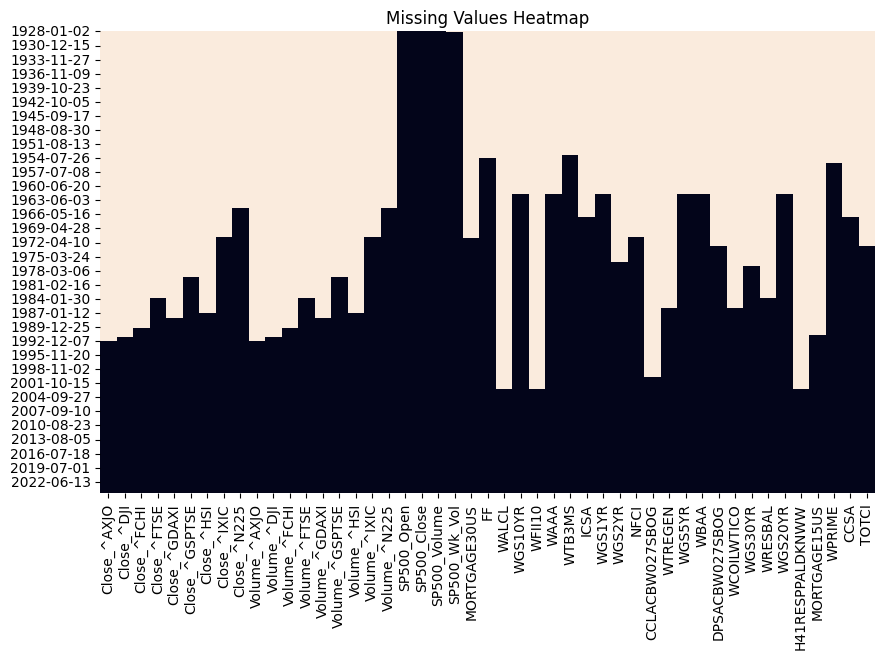

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(indices_macro_weekly.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [21]:
# Get the total number of missing values per column
missing_values = indices_macro_weekly.isnull().sum()

# Get the total number of rows in the DataFrame
total_rows = len(indices_macro_weekly)

# Calculate the percentage of missing values per column
missing_percentage = pd.DataFrame({'pct_missing': (missing_values / total_rows) * 100})

missing_percentage.head()

,pct_missing
Close_^AXJO,66.969937
Close_^DJI,66.060127
Close_^FCHI,64.161392
Close_^FTSE,57.812500
Close_^GDAXI,61.926424


In [22]:
missing_percentage.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
pct_missing,47.0,47.536106,20.157479,0.0,35.106804,49.980222,61.926424,77.412975


In [23]:
drop_columns = missing_percentage[missing_percentage['pct_missing'] > missing_percentage['pct_missing'].quantile(0.85)].index
drop_columns

Index(['Close_^AXJO', 'Volume_^AXJO', 'WALCL', 'WFII10', 'CCLACBW027SBOG',
       'H41RESPPALDKNWW'],
      dtype='object')

In [24]:
indices_macro_weekly_cleaned = indices_macro_weekly.drop(drop_columns, axis=1)

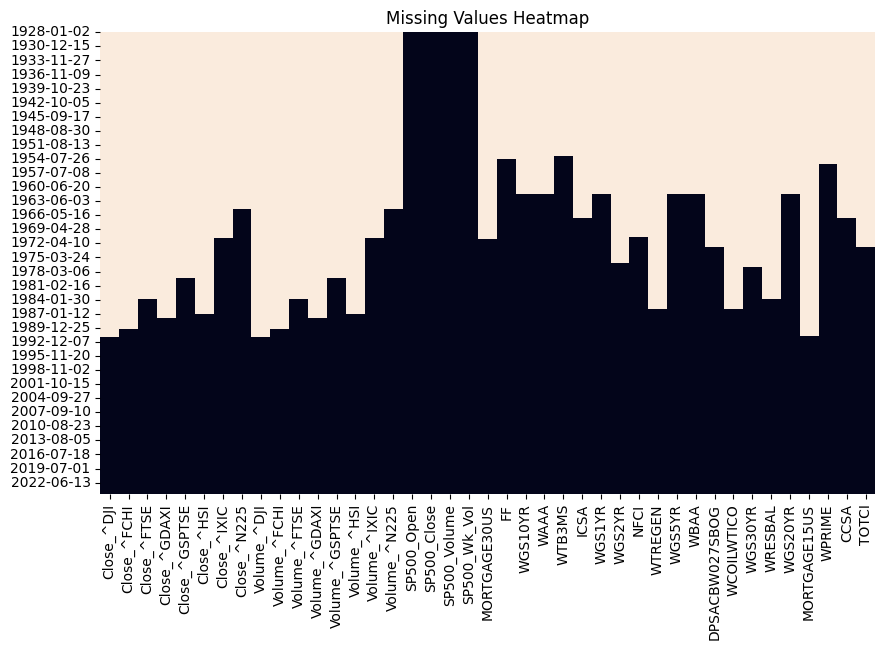

In [25]:
plt.figure(figsize=(10, 6))
sns.heatmap(indices_macro_weekly_cleaned.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()

In [26]:
indices_macro_weekly_cleaned = indices_macro_weekly_cleaned.dropna()

indices_macro_weekly_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1716 entries, 1992-01-06 to 2024-11-18
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Close_^DJI      1716 non-null   float64
 1   Close_^FCHI     1716 non-null   float64
 2   Close_^FTSE     1716 non-null   float64
 3   Close_^GDAXI    1716 non-null   float64
 4   Close_^GSPTSE   1716 non-null   float64
 5   Close_^HSI      1716 non-null   float64
 6   Close_^IXIC     1716 non-null   float64
 7   Close_^N225     1716 non-null   float64
 8   Volume_^DJI     1716 non-null   float64
 9   Volume_^FCHI    1716 non-null   float64
 10  Volume_^FTSE    1716 non-null   float64
 11  Volume_^GDAXI   1716 non-null   float64
 12  Volume_^GSPTSE  1716 non-null   float64
 13  Volume_^HSI     1716 non-null   float64
 14  Volume_^IXIC    1716 non-null   float64
 15  Volume_^N225    1716 non-null   float64
 16  SP500_Open      1716 non-null   float64
 17  SP500_Close     1716 no

In [27]:
# Export the resulting dataframe as csv

indices_macro_weekly_cleaned.to_csv('indices_macro_weekly_cleaned.csv')